In [22]:
import pandas as pd
import numpy as np
import sys
import os
from tqdm import tqdm
import sys
import time

# Data import

In [51]:
all_metrics = pd.read_csv('../data/metrics.csv')
all_metrics.rename(columns={'file_name': 'session_id'}, inplace=True)
all_metrics['session_id'] = all_metrics['session_id'].astype(str).str.rstrip('.jsonl')

In [32]:
#time windows metrics
time_window_metrics_df = pd.read_csv('../data/temporal_windows_metrics.csv')

In [3]:
#metadata for both argumentative and creative writing sessions
metadata_argumentative = pd.read_csv('../data/CoAuthor/add_data/metadata_argumentative.csv')
metadata_creative = pd.read_csv('../data/CoAuthor/add_data/metadata_creative.csv')

metadata_argumentative['type'] = 'argumentative'
metadata_creative['type'] = 'creative'

metadata = pd.concat([metadata_argumentative, metadata_creative], ignore_index=True)

In [4]:
#survey questionnaires for both argumentative and creative writing sessions
survey_argumentative = pd.read_csv('../data/CoAuthor/add_data/survey_argumentative.csv')
survey_creative = pd.read_csv('../data/CoAuthor/add_data/survey_creative.csv')

columns_argumentative = ['timestamp', 'worker_id', 'session_id', 'english_first_language', 'qualification', 'fluency', 'ideas_generation', 'quality', 'competency', 'writing','understanding', 'limitations', 'ease_of_use', 'satisfaction', 'confidence', 'ownership', 'written_by_human_decla', 'willingness_to_reuse', 'feedback']
columns_creative = ['timestamp', 'worker_id', 'session_id', 'english_first_language', 'fluency', 'ideas_generation', 'quality', 'competency', 'writing','understanding', 'limitations', 'ease_of_use', 'satisfaction', 'confidence', 'ownership', 'written_by_human_decla', 'willingness_to_reuse', 'feedback']

survey_argumentative.columns = columns_argumentative
survey_creative.columns = columns_creative

survey_argumentative.drop_duplicates(subset=['session_id'], keep='first', inplace=True)
survey_creative.drop_duplicates(subset=['session_id'], keep='first', inplace=True)

survey_combined = pd.concat([
    survey_argumentative[['session_id', 'written_by_human_decla', 'fluency', 'ideas_generation', 'quality', 'competency', 'writing','understanding', 'ease_of_use', 'satisfaction', 'confidence', 'ownership', 'willingness_to_reuse']],
    survey_creative[['session_id', 'written_by_human_decla', 'fluency', 'ideas_generation', 'quality', 'competency', 'writing','understanding', 'ease_of_use', 'satisfaction', 'confidence', 'ownership', 'willingness_to_reuse']]
], ignore_index=True)

In [52]:
#merge survey and metadata into a single dataframe
complete_data = metadata.merge(survey_combined, on='session_id', how='left')

In [53]:
all_metrics = all_metrics.merge(complete_data[['timestamp', 'session_id', 'worker_id', 'type', 'written_by_human','written_by_human_decla', 'fluency', 'ideas_generation', 'quality', 'competency', 'writing','understanding', 'ease_of_use', 'satisfaction', 'confidence', 'ownership', 'willingness_to_reuse']], on='session_id', how='left')

In [54]:
#fix formatting issues for declared authorship values
all_metrics['written_by_human_decla'] = all_metrics['written_by_human_decla'].replace(

    {'90-10%': 95, '99.9': 99, '97%': 97, '90%': 90}
)

In [55]:
all_metrics = all_metrics.dropna(subset=['written_by_human_decla'])
all_metrics = all_metrics.dropna(subset=['written_by_human'])

all_metrics['written_by_human'] = all_metrics['written_by_human'].astype(int)
all_metrics['written_by_human_decla'] = all_metrics['written_by_human_decla'].astype(int)

In [57]:
#Only keep time windows for sessions present in all_metrics (for which metadata and survey data are available)
time_window_metrics_df = time_window_metrics_df[time_window_metrics_df['session_id'].isin(all_metrics['session_id'].tolist())]

In [58]:
time_window_metrics_df

,session_id,window_start,window_end,nb_gpt_calls,nb_used_suggestions,nb_modified_suggestions,nb_rejected_suggestions,nb_accepted_as_it_is_suggestions,nb_sentences_total,nb_sentences_full_GPT,nb_sentences_full_user,nb_sentences_GPT_user,GAI_dependence,writing_autonomy,writing_collaboration,time_window
0,e0435f4cf6fc435c872ffc5b66b66b0c,2021-08-16 07:00:41.033,2021-08-16 07:01:41.033,1,1,0,0,1,4,0,0,4,0.000000,0.000000,1.0,0
1,e0435f4cf6fc435c872ffc5b66b66b0c,2021-08-16 07:01:41.033,2021-08-16 07:02:41.033,0,0,0,0,0,2,0,2,0,0.000000,1.000000,0.0,1
2,e0435f4cf6fc435c872ffc5b66b66b0c,2021-08-16 07:02:41.033,2021-08-16 07:03:41.033,1,1,0,0,1,4,1,3,0,0.250000,0.750000,0.0,2
3,e0435f4cf6fc435c872ffc5b66b66b0c,2021-08-16 07:03:41.033,2021-08-16 07:04:41.033,1,1,0,0,1,3,1,2,0,0.333333,0.666667,0.0,3
4,e0435f4cf6fc435c872ffc5b66b66b0c,2021-08-16 07:04:41.033,2021-08-16 07:05:41.033,1,0,0,1,0,2,0,2,0,0.000000,1.000000,0.0,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16618,396eb60f16924286997ddd4db4517074,2021-08-20 03:57:06.723,2021-08-20 03:58:06.723,1,1,0,0,1,3,1,2,0,0.333333,0.666667,0.0,5
16619,396eb60f16924286997ddd4db4517074,2021-08-20 03:58:06.723,2021-08-20 03:59:06.723,0,0,0,0,0,2,0,2,0,0.000000,1.000000,0.0,6
16620,396eb60f16924286997ddd4db4517074,2021-08-20 03:59:06.723,2021-08-20 04:00:06.723,0,0,0,0,0,4,0,4,0,0.000000,1.000000,0.0,7
16621,396eb60f16924286997ddd4db4517074,2021-08-20 04:00:06.723,2021-08-20 04:01:06.723,0,0,0,0,0,5,0,5,0,0.000000,1.000000,0.0,8


# Formatting time series data

In [59]:
from tslearn.metrics import dtw
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from tslearn.utils import to_time_series_dataset

In [60]:
sys.path.append('../src/')
sys.path.append('../src/scripts_shibani')

In [61]:
from time_series import *

In [62]:
# Add time_window index per session
time_window_metrics_df['time_window'] = time_window_metrics_df.groupby('session_id').cumcount()

/var/folders/nc/7q3l6kb55dzbm2hnx3_kn63wnhywfc/T/ipykernel_38568/1857272857.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  time_window_metrics_df['time_window'] = time_window_metrics_df.groupby('session_id').cumcount()


In [63]:
# List of explored writer-GenAI collaboration metrics
features = ['nb_gpt_calls', 'nb_modified_suggestions', 'nb_rejected_suggestions', 'nb_accepted_as_it_is_suggestions']

In [64]:
sessions_list, sessions_ids = prepare_timeseries_data(time_window_metrics_df, features)

In [65]:
# Convert to tslearn format with automatic padding (add NaN for shorter series)
X = to_time_series_dataset(sessions_list)

# Clustering on time series data with DTW similarity metric

In [66]:
from tslearn.clustering import TimeSeriesKMeans

## $k$-means optimization

In [67]:
inertias = [] 
k_range = range(2, 11)


print("\n=== Clustering ===")
for k in tqdm(k_range):
    start_time = time.time()
    
    model = TimeSeriesKMeans(
        n_clusters=k, 
        metric="dtw", 
        max_iter=10,
        max_iter_barycenter=10,
        random_state=42,
        n_jobs=-1,
        verbose=0
    )
    labels_v2 = model.fit_predict(X) 
    
    inertias.append(model.inertia_)


=== Clustering ===


100%|██████████| 9/9 [18:13<00:00, 121.48s/it]


In [71]:
# Create a DataFrame to store inertia values
optimization_results = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias
})

print("\n=== Results Table ===")
print(optimization_results.to_string(index=False))


=== Results Table ===
 k   inertia
 2 28.617100
 3 26.150948
 4 22.828238
 5 22.001634
 6 19.948611
 7 19.727221
 8 18.837261
 9 18.376252
10 18.369241


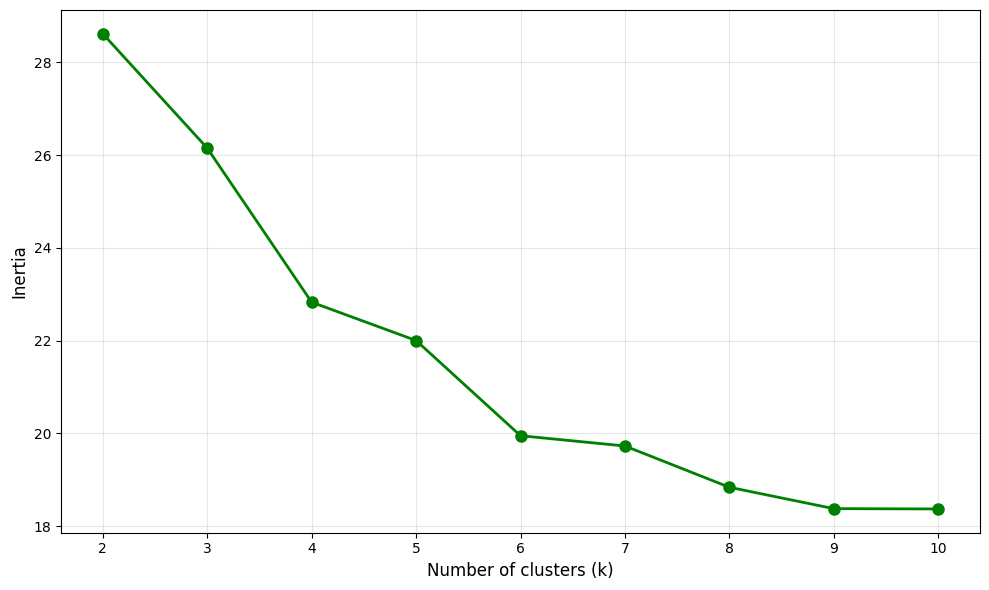

In [72]:
k_range = range(2, 11)
inertias = optimization_results['inertia'].tolist()

plt.figure(figsize=(10, 6))
plt.plot(k_range, inertias, 'go-', linewidth=2, markersize=8)
plt.xlabel('Number of clusters (k)', fontsize=12)
plt.ylabel('Inertia', fontsize=12)
# plt.title('Elbow Method - Inertia Evolution', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Apply $k$-means with optimal number of clusters

In [73]:
n_clusters_optimal = 6

In [74]:
model = TimeSeriesKMeans(
    n_clusters=n_clusters_optimal, 
    metric="dtw", 
    max_iter=10,
    max_iter_barycenter=10,
    random_state=42,
    n_jobs=-1,
    verbose=0
)

labels = model.fit_predict(X) 

In [76]:
# Add cluster labels to session IDs
cluster_assignments = pd.DataFrame({
    'session_id': sessions_ids, 
    'cluster': labels
})

print(f"Number of sessions per cluster:")
print(cluster_assignments['cluster'].value_counts().sort_index())

print(f"\nTotal sessions: {len(cluster_assignments)}")

Number of sessions per cluster:
cluster
0     81
1    179
2    155
3    192
4    565
5     69
Name: count, dtype: int64

Total sessions: 1241


In [78]:
all_metrics = all_metrics.merge(cluster_assignments, on='session_id', how='inner')

In [79]:
from visualization import *

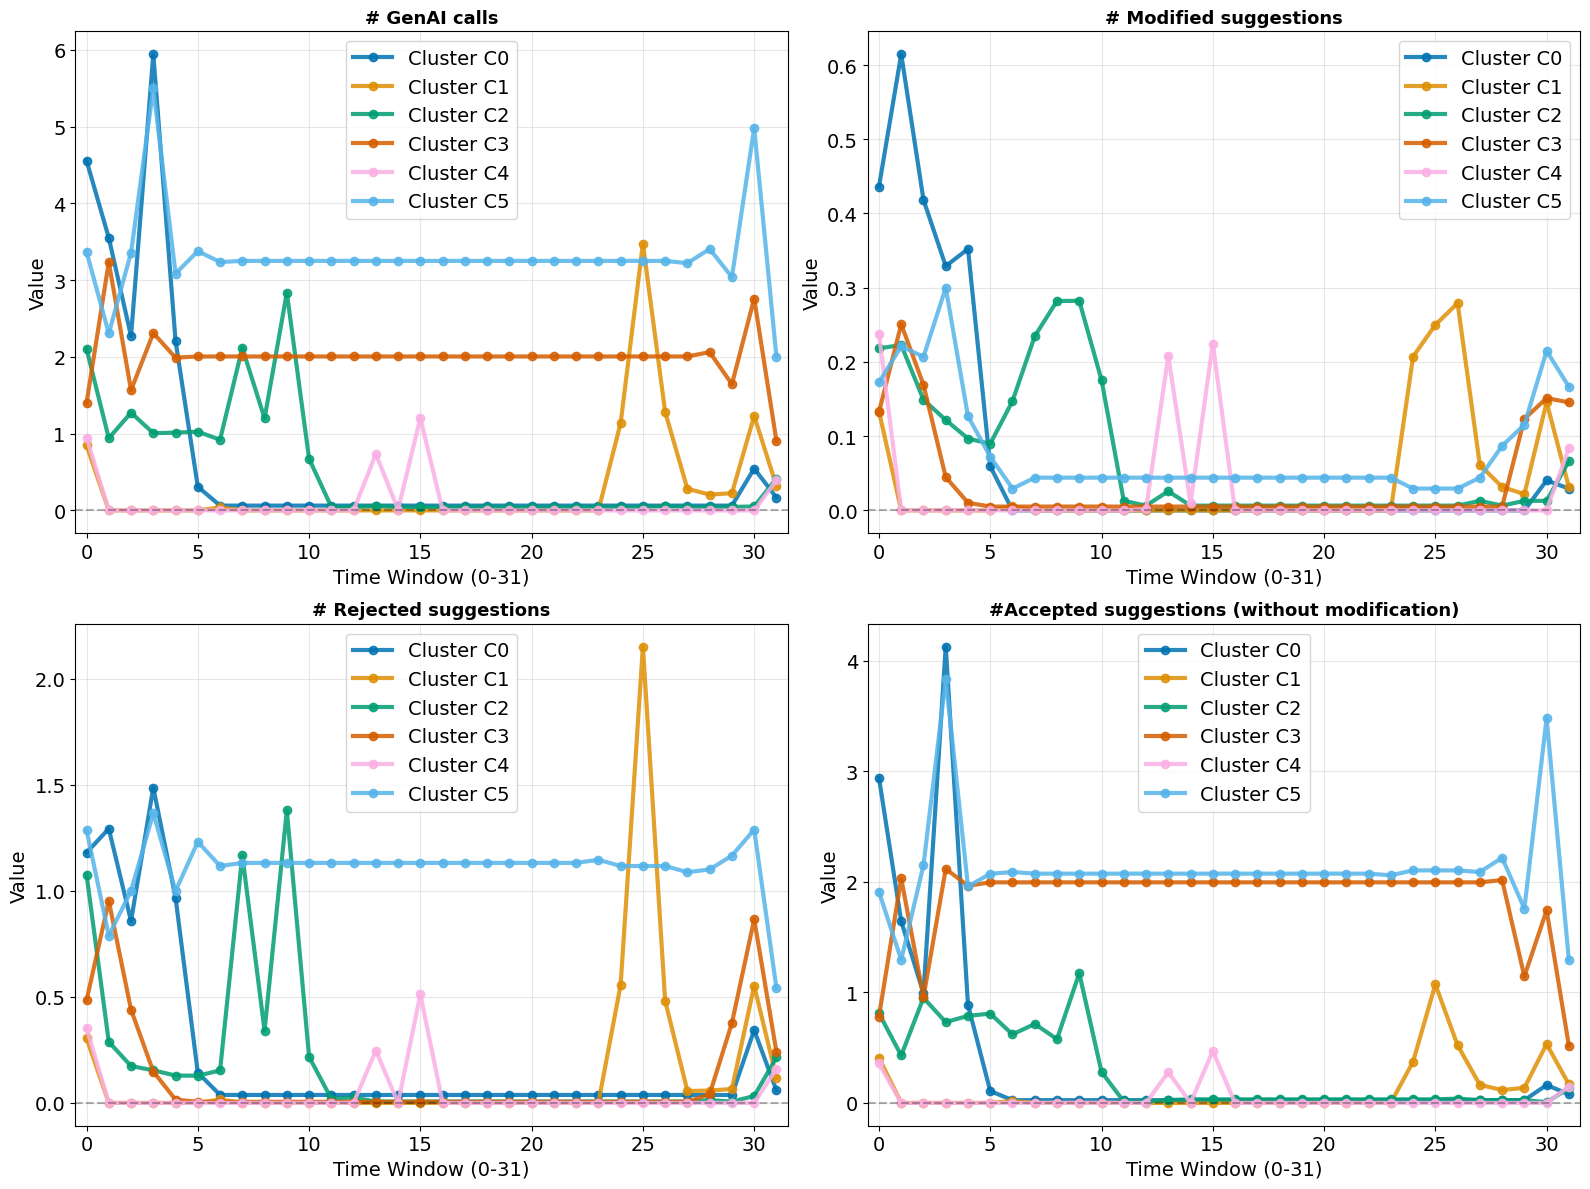

In [80]:
barycenters = model.cluster_centers_

plot_barycenters_per_feature(barycenters, features, n_clusters_optimal=6, save_fig=True)

In [81]:
#Save all_metrics for further analysis
all_metrics.to_csv('../data/all_metrics.csv', index=None)